In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import json
import sys
import numpy as np
from pathlib import Path
import yaml
from typing import Dict, Any
import time
from floris import FlorisModel, TimeSeries
import matplot2tikz
plt.style.use('default')

BASELINE_HR1_POWER = 63.492160278290314  # megawatts of unyawed HR1
KEYS = ["best_yaw", "per_case_power_MW", "wind_dir_deg", "wind_speed", "weights"]

def load_json(path: Path):
    # Changed path type hint to Path, as / operator creates Path objects
    with open(path, 'r') as f:
        return json.load(f)

# Serial-Refine JAX data
sr_data = np.load(Path(rf"..\DiffWake\results\yaw_serial_hr1\20260309_172931\arrays.npz"))
sr_meta = load_json(rf"..\DiffWake\results\yaw_serial_hr1\20260309_172931\meta.json")
# SLSQP JAX data
slsqp_data = np.load(Path(rf"..\DiffWake\results\.\yaw_slsqp_hr1\20260309_173450\arrays.npz"))
slsqp_meta = load_json(rf"..\DiffWake\results\yaw_slsqp_hr1\20260309_173450\meta.json")

# Bayex JAX data
bo_data = np.load(Path(rf"..\DiffWake\results\yaw_bayes_hr1\20260310_095506\arrays.npz"))
bo_meta = load_json(rf"..\DiffWake\results\yaw_bayes_hr1\20260310_095506\meta.json")


## Re-run Bayesian optimisation on Horns Rev 1

In [3]:
# # Gets the absolute path of the directory containing the current script
# current_dir = os.getcwd()
#
# # If 'optimizers' is one level up from this script, add the parent directory
# parent_dir = os.path.dirname(current_dir)
# sys.path.append(parent_dir)
#
# from optimizers.yaw_optimizer_bayes import YawOptimizationBayesian

In [4]:
# # Load YAML configuration files
# def _load_yaml(path: Path) -> Dict[str, Any]:
#     with open(path, "r", encoding="utf-8") as f:
#         return yaml.safe_load(f) or {}
#
# # Get AEP improvement as a percentage
# def baseline_improvement(base_val, opt_val):
#     return (opt_val - base_val) * 100 / base_val
#
# # Set turibne library path
# turbine_library = "../external_turbines/vesta_v802MW.yaml"
# sim_yaml = rf"E:\Aeronautics\fyp\DiffWake\data\horn\gch.yaml"
#
# # Optimisation parameters
# opt_options = {"n_calls": 440,
#                "n_initial_points": 240,
#                "acq_func": "LCB",
#                "kappa": 2.576,
#                "verbose": True,
#                "random_state": 0,
#                "initial_point_generator": "lhs",
#                }
#
# fmodel = FlorisModel(sim_yaml)
# fmodel.run()
# optimizer = YawOptimizationBayesian(fmodel, opt_options=opt_options)
# baseline_power = fmodel.get_farm_power()
# start_time = time.perf_counter()
# df_opt = optimizer.optimize()
# end_time = time.perf_counter()

In [61]:
# optimal_yaw_angles = (
#     df_opt[(df_opt["wind_direction"] == 270.0) & (df_opt[0]["wind_speed"] == 9.6)].yaw_angles_opt.values[0]
# ).reshape(1, -1)
#
# fmodel.set(yaw_angles=optimal_yaw_angles)
# fmodel.run()
# optimal_power = fmodel.get_farm_power()

optimal_power = df_opt[0]['farm_power_opt']

In [62]:
print(f"Baseline power: {baseline_power[0]/1e6:.14f} MW")
print(f"Optimised power: {optimal_power[0]/1e6:.14f} MW")
print(f"Runtime: {end_time - start_time:.4f} s")

Baseline power: 63.50592840125507 MW
Optimised power: 69.47952938810555 MW
Runtime: 6577.3838 s


In [72]:
df_opt[0]['yaw_angles_opt'][0].shape

(80,)

In [75]:
fmodel.set(yaw_angles=df_opt[0]['yaw_angles_opt'][0].reshape(1, -1))
fmodel.run()
optimal_power = fmodel.get_farm_power()

In [17]:
floris_slsqp = "gch2_scipy_0904"
floris_sr = "gch2_serial_1204"
floris_bo = "gch2_BO_11_11_2025_13-50"

# FLORIS data in MW
sr_data_floris = {'baseline_power_MW': 63.50592840125507, 'per_case_power_MW': 74.6322270601, 'runtime': 103.723}
slsqp_data_floris = {'baseline_power_MW': 63.50592840125507, 'per_case_power_MW': 74.7013287619, 'runtime': 1358.293}
bo_data_floris = {'baseline_power_MW': 63.50592840125507, 'per_case_power_MW': 69.47952938810555, 'runtime': 6577.3838}
baseline_power = 63.50592840125507
sr_data_floris['power_increase_pct'] = (sr_data_floris['per_case_power_MW']-63.50592840125507)/sr_data_floris['baseline_power_MW'] * 100
slsqp_data_floris['power_increase_pct'] = (slsqp_data_floris['per_case_power_MW']-63.50592840125507)/slsqp_data_floris['baseline_power_MW'] * 100
bo_data_floris['power_increase_pct'] = (bo_data_floris['per_case_power_MW']-63.50592840125507)/bo_data_floris['baseline_power_MW']*100

data = {
    "sr_data_floris": sr_data_floris,
    "slsqp_data_floris": slsqp_data_floris,
    "bo_data_floris": bo_data_floris
}

# Write the data to a JSON file
with open('floris_results.json', 'w') as json_file:
    json.dump(data, json_file, indent=4)

In [18]:
sr_jax_runtime = sr_meta['elapsed_time']
sr_floris_runtime = sr_data_floris['runtime']
sr_jax_power = sr_meta['power_increase_pct']
sr_floris_power = sr_data_floris['power_increase_pct']

slsqp_jax_runtime = slsqp_meta['elapsed_time']
slsqp_floris_runtime = slsqp_data_floris['runtime']
slsqp_jax_power = slsqp_meta['power_increase_pct']
slsqp_floris_power = slsqp_data_floris['power_increase_pct']

bo_jax_runtime = bo_meta['elapsed_time']
bo_floris_runtime = bo_data_floris['runtime']
bo_jax_power = bo_meta['power_increase_pct']
bo_floris_power = bo_data_floris['power_increase_pct']

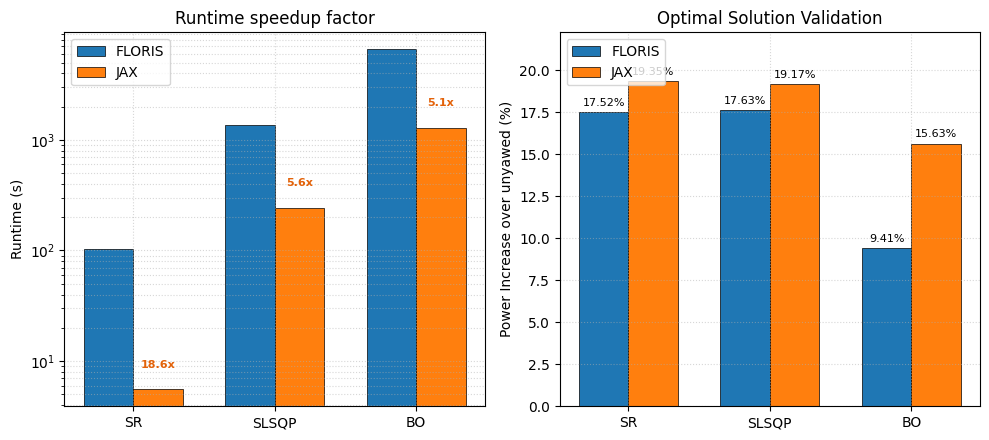

In [25]:
sr_jax_runtime = sr_meta['elapsed_time']
sr_floris_runtime = sr_data_floris['runtime']
sr_jax_power = sr_meta['power_increase_pct']
sr_floris_power = sr_data_floris['power_increase_pct']

slsqp_jax_runtime = slsqp_meta['elapsed_time']
slsqp_floris_runtime = slsqp_data_floris['runtime']
slsqp_jax_power = slsqp_meta['power_increase_pct']
slsqp_floris_power = slsqp_data_floris['power_increase_pct']

bo_jax_runtime = bo_meta['elapsed_time']
bo_floris_runtime = bo_data_floris['runtime']
bo_jax_power = bo_meta['power_increase_pct']
bo_floris_power = bo_data_floris['power_increase_pct']

# --- Structure data ---
methods = ['SR', 'SLSQP', 'BO']
floris_runtimes = [sr_floris_runtime, slsqp_floris_runtime, bo_floris_runtime]
jax_runtimes = [sr_jax_runtime, slsqp_jax_runtime, bo_jax_runtime]

floris_powers = [sr_floris_power, slsqp_floris_power, bo_floris_power]
jax_powers = [sr_jax_power, slsqp_jax_power, bo_jax_power]

# --- Set up clean layout dimensions ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))
x = np.arange(len(methods))
width = 0.35

# ==========================================
# SUBPLOT 1: Computational Runtime Comparison
# ==========================================
ax1.bar(x - width/2, floris_runtimes, width, label='FLORIS', color='#1f77b4', edgecolor='black', linewidth=0.5)
ax1.bar(x + width/2, jax_runtimes, width, label='JAX', color='#ff7f0e', edgecolor='black', linewidth=0.5)

ax1.set_ylabel('Runtime (s)')
ax1.set_title('Runtime speedup factor')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.set_yscale('log')
ax1.grid(True, which="both", ls=":", alpha=0.5)
ax1.legend(loc='upper left')

# Add clean single-line speedup annotations above JAX bars
for i in range(len(methods)):
    speedup = floris_runtimes[i] / jax_runtimes[i]
    ax1.text(x[i] + width/2, jax_runtimes[i] * 1.5, f'{speedup:.1f}x',
             ha='center', va='bottom', fontsize=8, fontweight='bold', color='#e36209')

# ==========================================
# SUBPLOT 2: Optimal Solution Validation
# ==========================================
rects3 = ax2.bar(x - width/2, floris_powers, width, label='FLORIS', color='#1f77b4', edgecolor='black', linewidth=0.5)
rects4 = ax2.bar(x + width/2, jax_powers, width, label='JAX', color='#ff7f0e', edgecolor='black', linewidth=0.5)

ax2.set_ylabel('Power Increase over unyawed (%)')
ax2.set_title('Optimal Solution Validation')
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.grid(True, which="major", ls=":", alpha=0.5)
ax2.legend(loc='upper left')

# Add value labels above the validation bars
for rect in rects3 + rects4:
    height = rect.get_height()
    ax2.annotate(f'{height:.2f}%',
                 xy=(rect.get_x() + rect.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=8)

# Set height constraint to protect labels from clipping
ax2.set_ylim(0, max(max(floris_powers), max(jax_powers)) * 1.15)
plt.tight_layout()

matplot2tikz.save(rf"E:\Aeronautics\fyp\plotting\latex\hr1_case_study.tex")